# Lesson 09a: Allegro as a Strictly Local Equivariant Potential

**What you will learn**

- Why message passing makes the receptive field grow as $N_\text{layer} \times
  r_c$ and why that hurts parallel scaling for large systems.
- Allegro's strictly local decomposition of the energy into pairwise terms
  $E_{ij}$, each computed by a deep equivariant network with no message passing
  between environments.
- The two-track layer design: an invariant scalar latent-space track $x^{ij}$
  and an equivariant tensor latent-space track $V^{ij}$, coupled once per layer
  by a weighted tensor product with spherical harmonics of the local
  environment.
- Why scalar features may pass through arbitrary MLPs while $\ell > 0$ features
  may not.
- The scaling argument: independent pair terms allow embarrassingly parallel
  force evaluation and the 
  [Allegro paper](https://doi.org/10.1038/s41467-022-29939-5)'s 100-million-atom demonstration.
- A side-by-side comparison of NequIP and Allegro.

**Prerequisites:** 

- [Lesson 02a](02a_irreps_in_e3nn.ipynb) and [2b](02b_spherical_harmonics.ipynb): irreps, spherical harmonics,
- [Lesson 04](04_nonlinearities_and_gates.ipynb): equivariant nonlinearities, gates,
- [Lesson 05a](05a_atomistic_graphs.ipynb): graphs, radial bases,
- [Lesson 08a](08a_nequip_theory.ipynb): NequIP theory.

In [1]:
import sys; sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.equivariance import assert_equivariant, equivariance_error

torch.manual_seed(0)
# This is a theory notebook: the code is illustrative and cheap, so we use
# float64 everywhere — equivariance checks then sit at machine precision.
torch.set_default_dtype(torch.float64)
device = "cpu"
print(torch.__version__)

2.7.1+cu126


## The cost of message passing: receptive fields

Atom-centered message-passing neural networks (MPNNs), such as SchNet (Lesson
07a), DimeNet (Lesson 07b), NequIP (Lessons 08a-c) keep a hidden state
$\mathbf{h}_i^t$ on every central atom $i$ and update it by exchanging messages
along the edges of the atomic graph within a local cutoff radius. That is:

$$\mathbf{m}_i^{t+1} = \sum_{j \in \mathcal{N}(i)} M_t\!\left(\mathbf{h}_i^t, \mathbf{h}_j^t, \mathbf{e}_{ij}\right)$$

$$\mathbf{h}_i^{t+1} = U_t\!\left(\mathbf{h}_i^t, \mathbf{m}_i^{t+1}\right)$$

where $\mathcal{N}(i)$ is the set of neighbors of atom $i$ within the **local
cutoff radius**, $r_{c,l}$, $\mathbf{e}_{ij}$ are edge features (typically
functions of the interatomic distance $r_{ij}$), and $M_t$, $U_t$ are the
learned message and update functions of layer $t$.

After one layer (i.e., at iteration $t=1$), $\mathbf{h}_i$ knows about atoms
within $r_{c,l}$; after two layers, it knows about atoms within $2\,r_{c,l}$
(its neighbors' neighborhoods), and so on. With $N_\text{layer}$ message-passing
layers, the **effective cutoff radius** is

$$r_{c,e} = N_\text{layer} \cdot r_{c,l},$$

and the number of atoms inside the receptive field grows **cubically** in
$r_{c,e}$. For example, the liquid water at ambient conditions with a typical
setting of $N_\text{layer}=6$ and $r_{c,l}=6\,\text{Å}$ gives $r_{c,e} =
36\,\text{Å}$. Each atom then has $\approx 96$ atoms in its local 6 Å
environment but 20,834 atoms inside the extended 36 Å effective cutoff radius
(receptive field) which affect the final state of the central atom and
contribute to its local environment (impacting properties such as energy,
forces, and other local physical quantities).

Let's visualize the relationship between the number of atoms in the receptive
field vs. the number of message-passing layers in a typical MPNN model for a
liquid water system.

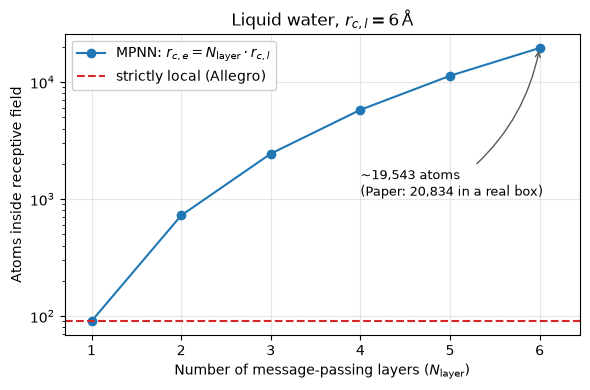

In [2]:
# Atoms / A^3  (~0.0334 molecules/A^3 x 3 atoms)
rho = 0.10

# Local cutoff in Angstroms
r_c = 6.0

# Number of message-passing layers
n_layers = np.arange(1, 7)

# Effective cutoff radius
r_eff = n_layers * r_c

# Number of atoms inside the receptive field
# ~ cubic growth
atoms_in_receptive_field = 4 / 3 * np.pi * r_eff**3 * rho

# Number of atoms in the strictly local environment (Allegro)
atoms_local = 4 / 3 * np.pi * r_c**3 * rho

# Visualization of the relationship between the number of atoms in the receptive
# field and the number of message-passing layers
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(n_layers, atoms_in_receptive_field, "o-", label=r"MPNN: $r_{c,e}=N_\mathrm{layer} \cdot r_{c,l}$")
ax.axhline(atoms_local, color="C3", ls="--", label="strictly local (Allegro)")
# Call out the deepest MPNN point from the empty wedge below the curve
ax.annotate(f"~{atoms_in_receptive_field[-1]:,.0f} atoms\n(Paper: 20,834 in a real box)",
            xy=(6, atoms_in_receptive_field[-1]), xytext=(4, 1340),
            fontsize=9, va="center",
            arrowprops=dict(arrowstyle="->", color="0.35",
                            connectionstyle="arc3,rad=0.2"))
ax.set_xlim(0.7, 6.45)
ax.set_xlabel(r"Number of message-passing layers ($N_\mathrm{layer}$)")
ax.set_ylabel(r"Atoms inside receptive field")
ax.set_title(r"Liquid water, $r_{c,l} = 6\,\mathrm{\AA}$")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)
fig.tight_layout()

### Why this hurts parallel scaling

Large-scale MD codes (e.g. LAMMPS) parallelize their work by **spatial domain
decomposition**: each worker owns a region of space and communicates a "halo" of
ghost atoms with its neighbors. The halo thickness must cover the *interaction
range* of the potential:

- For an MPNN, that range is $r_{c,e} = N_\text{layer}\, r_{c,l}$. Every worker
  must access the high-dimensional hidden states $\mathbf{h}_i$ of all $\approx$
  20,000 atoms in the extended environment. It would also be worse for the force
  computations which are computed through back-propagation of the gradients
  along the same multi-hop graph which requires iterated communication at every
  step.

- A **strictly local** model only needs the states associated with the
  $\approx$ 96 atoms (in the example above, $6^3 = 216$ pair states) inside a
  single cutoff sphere.

This is exactly why strictly local classical potentials and descriptor methods
(e.g., Behler-Parrinello HDNNPs, GAP, SNAP, ACE, ...) can scale to enormous systems.

## Strictly local pairwise-energy decomposition

The Allegro model decomposes the total potential energy of an into per-atom
energy contributions,

$$E_\text{system} = \sum_i^N \sigma_{Z_i} E_i + \mu_{Z_i}$$

where $Z_i$ is the chemical species of atom $i$, and $\sigma_{Z_i}$ and
$\mu_{Z_i}$ denote per-species scale and shift parameters, respectively. Both
$\sigma_{Z_i}$ and $\mu_{Z_i}$ may be trainable parameters.

Unlike most MLIPs, however, Allegro further decomposes each per-atom energy into
**pairwise** energies, indexed by the central atom $i$ and one of its neighbors
$j$:

$$E_i = \sum_{j \in \mathcal{N}(i)} \sigma_{Z_i, Z_j} E_{ij}$$

Here, $\sigma_{Z_i,Z_j}$ is the per-species-pair scale factor, which may also be
a trainable parameter. 

Atomic forces are the exact negative gradient of the total energy with respect
to the atomic positions. As such, the Allegro's force field becomes
energy-conserving by construction:

$$\vec{F}_i = -\nabla_i E_\text{system}$$

From the theoretical construction, two points may become easy to misread:

1. While **$E_{ij}$ are indexed by atom $i$ and $j$,** their value may depend on
   all neighboring atoms $k \in \mathcal{N}(i)$ of the central atom $i$. The network
   couples each pair to its full local environment, making Allegro a many-body
   potential.

2. **$E_{ij} \neq E_{ji}$, by design.** $E_{ij}$ depends on the environment of
   $i$, while $E_{ji}$ depends on the environment of $j$. The two terms are
   computed independently and only their sum is physically meaningful.

So, in Allegro, the strict locality means that everything depends only on atoms
within **one** cutoff sphere, no matter how deep the network architecture gets.

## The coupled latent spaces

Allegro processes each ordered pair $(i,j)$ with two coupled latent spaces:

| track | symbol | content | transformation |
|---|---|---|---|
| **scalar space** | $x^{ij,L}$ | invariant latent features of pair $(i,j)$ at layer $L$ | invariant ($\ell = 0$) |
| **tensor space** | $V^{ij,L}_{n,\ell,p}$ | equivariant features: $n$ = channel, irrep $(\ell, p)$ with $\ell = 0 \dots \ell_\text{max}$, parity $p \in \{-1, 1\}$ | Wigner matrices $D^{(\ell)}(g)$, $\times (\pm 1)$ for parity |

**Why are there two latent spaces?**

- A **scalar** ($\ell = 0$) feature remains unchanged under rotations. Thus, any
  elementwise nonlinearity such as $\tanh$, SiLU, a whole MLP *etc.* maps
  invariants to invariants. The scalar latent space side of the network can
  therefore use any ordinary deep neural network operation which are often
  cheap, expressive, and unconstrained.
- An $\ell > 0$ feature **mixes its components under rotation**. Applying a
  nonlinearity componentwise breaks equivariance, because $\phi(D(g)\,V) \neq
  D(g)\,\phi(V)$ for a nonlinear $\phi$. The tensor latent space side of the
  network is therefore restricted to the equivariant operations such as those we
  built in Lessons 03-04, which involved linear channel mixing **within an
  irrep**, and tensor products to **combine irreps**:

$$(\mathbf{x} \otimes \mathbf{y})_{\ell_\text{out}, m_\text{out}} = \sum_{m_1,
m_2} \begin{pmatrix} \ell_1 & \ell_2 & \ell_\text{out} \\ m_1 & m_2 &
m_\text{out} \end{pmatrix} \mathbf{x}_{\ell_1, m_1}\, \mathbf{y}_{\ell_2, m_2}$$

with the Wigner $3j$ symbol as the coupling coefficients (equivalent to the
Clebsch–Gordan coupling of Lesson 03a).

Each Allegro layer couples the scalar and tensor tracks in both directions: the
scalar track generates the weights of the tensor-track tensor product, and the
scalar ($\ell=0$) outputs of that tensor product are fed back into the scalar
track. 

Let's first verify the asymmetry that motivates the design of the Allegro
architecture.

In [3]:
# An elementwise nonlinearity is equivariant on scalars (0e) but NOT on vectors (1o)
err_scalars = equivariance_error(torch.tanh, "8x0e", "8x0e")
err_vectors = equivariance_error(torch.tanh, "8x1o", "8x1o")

# Print the equivariance errors for scalars and vectors
print(f"tanh on 8x0e: max equivariance error = {err_scalars:.2e}   (invariant --> fine)")
print(f"tanh on 8x1o: max equivariance error = {err_vectors:.2e}   (breaks equivariance!)")

tanh on 8x0e: max equivariance error = 0.00e+00   (invariant --> fine)
tanh on 8x1o: max equivariance error = 8.22e-01   (breaks equivariance!)


## Initial two-body embedding

**Scalar space route (layer $L=0$)**: The atomic pair $(i,j)$ is embedded from
its species pair $(Z_i, Z_j)$ and distance $r_{ij}$,

$$x^{ij, L=0} = \mathrm{MLP}_\text{two-body}\!\Big( \mathrm{1Hot}(Z_i)\, \Vert\,
\mathrm{1Hot}(Z_j)\, \Vert\, B(r_{ij}) \Big) \cdot u(r_{ij})$$

$$B(r_{ij}) = \big( B_1(r_{ij})\, \Vert \ldots \Vert\, B_{N_\text{basis}}(r_{ij}) \big)$$

where $\Vert$ denotes concatenation, $\mathrm{1Hot}(\cdot)$ is a one-hot
encoding for species, $B_n$ are Bessel radial basis functions, and $u(r_{ij})$
is the smooth polynomial cutoff envelope (both from Lesson 05b; we implement
them in 09b). Multiplying by $u(r_{ij})$ makes the embedding and everything
downstream go smoothly to zero at the cutoff.

**Tensor space route (layer $L=0$)**: The initial equivariant features are a
learned linear embedding of the spherical-harmonic projection of the **central
pair direction** $\hat{r}_{ij}$ (with $\vec{r}_{ij} = \vec{r}_j - \vec{r}_i$,
the convention used throughout this course):

$$V^{ij, L=0}_{n,\ell,p} = w^{ij, L=0}_{n,\ell,p}\, \vec{Y}^{\,ij}_{\ell,p}$$

$$w^{ij, L=0}_{n,\ell,p} = \mathrm{MLP}^{L=0}_\text{embed}\!\left(x^{ij, L=0}\right)_{n,\ell,p}$$

Here, $\vec{Y}^{\,ij}_{\ell,p}$ is the projection of $\hat{r}_{ij}$ onto the
real spherical harmonic of degree $\ell$ (parity $p = (-1)^\ell$; the $m$ index
is suppressed), $n = 0, \dots, n_\text{equivariant}-1$ is the channel index, and
the scalar weights, $w$, are predicted from the scalar space route. This
signifies the first instance of scalar $\to$ tensor coupling in Allegro.

## The Allegro layer

Each Allegro tensor-product layer has four components:

1. an MLP that generates weights to embed the central atom's environment,
2. an equivariant tensor product, which uses those weights,
3. an MLP that updates the scalar latent space with the scalar outputs of the
   tensor product,
4. an equivariant linear layer that mixes channels in the equivariant latent space.

Let's go through each of these components in more details.


### Tensor product with the embedded environment (Comps. 1 & 2)

The tensor product in the tensor space route couples the pair features,
$V^{ij,L-1}$, to **all other pairs $ik$ in the environment of $i$**:

$$V^{ij,L}_{n,(\ell_1,p_1,\ell_2,p_2) \to (\ell_\text{out},p_\text{out})} =
\sum_{k \in \mathcal{N}(i)} w^{ik,L}_{n,\ell_2,p_2} \left(
V^{ij,L-1}_{n,\ell_1,p_1} \otimes \vec{Y}^{\,ik}_{\ell_2,p_2} \right)$$

Because the tensor product is bilinear, the sum over neighbors can be pulled
inside the parenthesized term. This is a special example of the **density
trick**, which expresses the update as a single tensor product rather than one
tensor product per neighbor:

$$V^{ij,L}_{\cdots} = V^{ij,L-1}_{n,\ell_1,p_1} \otimes \left( \sum_{k \in
\mathcal{N}(i)} w^{ik,L}_{n,\ell_2,p_2}\, \vec{Y}^{\,ik}_{\ell_2,p_2} \right)$$

The bracketed sum is the **embedded environment** of atom $i$: a weighted
spherical-harmonic projection of the atomic density around $i$ similar to the
projection used in ACE and SOAP frameworks. Note that the weights are not a
fixed radial-chemical basis but are learned via the scalar space route:

$$w^{ik,L}_{n,\ell_2,p_2} =
\mathrm{MLP}^{L}_\text{embed}\!\left(x^{ik,L-1}\right)_{n,\ell_2,p_2}$$

where an embedded environment with a fixed and user-defined number of channels
($n_\text{equivariant}$) is constructed.

At layer $L > 1$, $x^{ik,L-1}$ already contains many-body information about the
environment of $i$. As such, the environment embedding becomes increasingly
informative with increasing the network depth. All tensor-product paths
satisfying $|\ell_1 - \ell_2| \le \ell_\text{out} \le \ell_1 + \ell_2$,
$p_\text{out} = p_1 p_2$, and $\ell_\text{out} \le \ell_\text{max}$ are
candidates and which ones to include is a hyperparameter.

### The latent MLP and tensor $\to$ scalar coupling (Comp. 3)

The scalar ($\ell_\text{out}=0,\, p_\text{out}=1$) outputs of the tensor product
are concatenated with the previous equivariantlatent features and compressed
back into the fixed-width scalar latent space route:

$$x^{ij,L} = \mathrm{MLP}^{L}_\text{latent}\!\Big( x^{ij,L-1}\, \Vert
\bigoplus_{(\ell_1,p_1,\ell_2,p_2)}
V^{ij,L}_{n,(\ell_1,p_1,\ell_2,p_2)\to(\ell_\text{out}=0,p_\text{out}=1)} \Big)
\cdot u(r_{ij})$$

After each layer, the scalar latent route additionally uses a **residual
update**, in which the new features are added to those of layer $L-1$. Residual
connections can help the scalar information propagate easily through depth.

### Linear mixing (Comp. 4)

The outputs of different tensor product paths, carrying the same irrep $(\ell,
p)$, are mixed back to $n_\text{equivariant}$ channels per irrep:

$$V^{ij,L}_{n,\ell,p} = \sum_{n', \text{paths}}
w^{L}_{n,n',\text{path}\to(\ell,p)}\; V^{ij,L}_{n',\text{path}\to(\ell,p)}$$

Here, $\text{path}$ replaces $(\ell_1,p_1,\ell_2,p_2)$. Note what is absent
here: no update ever reads features of pairs centered on other atoms and no
information ever propagates beyond $\mathcal{N}(i)$.

### The Allegrolayer in e3nn and irreps bookkeeping

Let's instantiate the equivariant core of one Allegro-style layer and watch the
irreps flow through it. We use $\ell_\text{max}=2$, $C = 4$ channels. The
channel index, $n$, is shared between the two tensor product inputs (e3nn's
`"uuu"` connection mode: channel $n$ of $V$ couples only to channel $n$ of the
environment). We keep only paths whose output irrep is one of the irreps of
$\vec{Y}$ ($0e$, $1o$, $2e$) which will be our hyperparameter choice.

First, we create our channel-wise tensor product function.

In [4]:
def channelwise_tp(irreps_V, irreps_env, allowed):
    """Weight-free channel-wise tensor product with all allowed paths."""
    
    # Convert the allowed irreps to a set for faster lookup
    allowed = {o3.Irrep(ir) for ir in allowed}
    
    # Initialize the output irreps and instructions for the tensor product
    irreps_out, instructions = [], []
    for i1, (mul, ir1) in enumerate(irreps_V):
        for i2, (_, ir2) in enumerate(irreps_env):
            
            # Selection rules (Lesson 03)
            for ir_out in ir1 * ir2:
                
                # Check if this output irrep is in the allowed set
                if ir_out in allowed:
                    
                    # Add an instruction for this allowed path
                    instructions.append((i1, i2, len(irreps_out), "uuu", False))
                    
                    # Record the output irrep for this path
                    irreps_out.append((mul, ir_out))
                    
    # Return the tensor product object with the computed output irreps and
    # instructions
    return o3.TensorProduct(irreps_V, irreps_env, o3.Irreps(irreps_out), instructions,
                            internal_weights=False, shared_weights=False)

We now use the channel-wise tensor product and the linear mixing layer to build
the equivariant core of the Allegro-style layer.

In [5]:
# n_equivariant channels
C = 4

# 1x0e + 1x1o + 1x2e
irreps_Y = o3.Irreps.spherical_harmonics(2)

# Tensor latent route
irreps_V = o3.Irreps([(C, ir) for _, ir in irreps_Y])

# Embedded environment: C weighted copies of Y
irreps_env = irreps_V

# Channel-wise tensor product with all allowed paths
tp = channelwise_tp(irreps_V, irreps_env, [ir for _, ir in irreps_V])

# Every path visible, zero weights inside
print(tp)

# Count the number of scalar (0e) paths in the tensor product
n_scalar_paths = sum(mul for mul, ir in tp.irreps_out if ir == o3.Irrep("0e"))

# Print the number of scalar (0e) paths and the total number of channel-wise paths
print(f"\nirrep-level paths: {len(tp.instructions)} (e3nn counts {len(tp.instructions)} x C = "
      f"{C * len(tp.instructions)} channel-wise paths above)")
print(f"scalar (0e) outputs fed back to the scalar track: {n_scalar_paths}")

# Linear mixing of the tensor product output back to the tensor latent route
linear_mix = o3.Linear(tp.irreps_out, irreps_V)

# Print the linear mixing layer
print(linear_mix)

TensorProduct(4x0e+4x1o+4x2e x 4x0e+4x1o+4x2e -> 4x0e+4x1o+4x2e+4x1o+4x0e+4x2e+4x1o+4x2e+4x1o+4x0e+4x2e | 44 paths | 0 weights)

irrep-level paths: 11 (e3nn counts 11 x C = 44 channel-wise paths above)
scalar (0e) outputs fed back to the scalar track: 12
Linear(4x0e+4x1o+4x2e+4x1o+4x0e+4x2e+4x1o+4x2e+4x1o+4x0e+4x2e -> 4x0e+4x1o+4x2e | 176 weights)


Having the building blocks of Allegro-style layers, we can test them by applying
them to a sample input and observing the flow of irreps through the layer.

In [6]:
# Trace one layer update for a central atom i with 5 neighbors (fake data, real
# shapes)
n_edges, latent_dim = 5, 16

# Scalar latents of the pairs (i,k)
x_ik = torch.randn(n_edges, latent_dim)

# Displacement vectors
r_ik = torch.randn(n_edges, 3)

# Spherical harmonics of the displacement vectors
Y_ik = o3.spherical_harmonics(irreps_Y, r_ik, normalize=True, normalization="component")

# Weights from the scalar latent route
w = torch.nn.Linear(latent_dim, C * len(irreps_Y))(x_ik)
w = w.reshape(n_edges, C, len(irreps_Y))

# Embedded environment
blocks, idx = [], 0
for m, (_, ir) in enumerate(irreps_Y):
    
    #  Weight each Y irrep per channel...
    blk = w[:, :, m:m+1] * Y_ik[:, None, idx:idx + ir.dim]
    blocks.append(blk.reshape(n_edges, C * ir.dim))
    idx += ir.dim
    
#   ...then sum over neighbors k
env_i = torch.cat(blocks, dim=-1).sum(0, keepdim=True)

# Current pair features V^{ij,L-1}
V_ij = irreps_V.randn(1, -1)

# V x (embedded environment)
tp_out = tp(V_ij, env_i)

# 0e slice -> latent MLP input
scalars = tp_out[:, :n_scalar_paths]

# Linear mixing of the tensor product output to get the new pair features V_new
V_new = linear_mix(tp_out)

# Print shapes and irreps of the intermediate features
for name, t, irr in [("x_ik (scalar track)", x_ik, "-"), ("Y_ik", Y_ik, irreps_Y),
                     ("env_i", env_i, irreps_env), ("V_ij", V_ij, irreps_V),
                     ("tp_out", tp_out, tp.irreps_out.simplify()),
                     ("-> scalars to x-track", scalars, f"{n_scalar_paths}x0e"),
                     ("-> V_new (mixed)", V_new, irreps_V)]:
    print(f"{name:24s} shape {tuple(t.shape)!s:12s} irreps {irr}")

x_ik (scalar track)      shape (5, 16)      irreps -
Y_ik                     shape (5, 9)       irreps 1x0e+1x1o+1x2e
env_i                    shape (1, 36)      irreps 4x0e+4x1o+4x2e
V_ij                     shape (1, 36)      irreps 4x0e+4x1o+4x2e
tp_out                   shape (1, 140)     irreps 4x0e+4x1o+4x2e+4x1o+4x0e+4x2e+4x1o+4x2e+4x1o+4x0e+4x2e
-> scalars to x-track    shape (1, 12)      irreps 12x0e
-> V_new (mixed)         shape (1, 36)      irreps 4x0e+4x1o+4x2e


### Equivariance check

An equivariant Allegro layer must be built from equivariant building blocks
(tensor product and linear mixing). We test the O(3)-equivariance of these two
units with the course harness, treating the pair features and the environment as
one concatenated input.

In [15]:
# Concatenated (V, env) input
irreps_in = irreps_V + irreps_env

# Split the concatenated input into V and env parts
split = lambda z: (z[:, :irreps_V.dim], z[:, irreps_V.dim:])

# Equivariance check for the tensor product and linear mixing units
print("tensor product:                     ", end="")
assert_equivariant(lambda z: tp(*split(z)), irreps_in, tp.irreps_out)
print("tensor product + mixing:            ", end="")
_ = assert_equivariant(lambda z: linear_mix(tp(*split(z))), irreps_in, irreps_V)

tensor product:                     equivariant!  (max error 1.707e-10 over random O(3) elements)
tensor product + mixing:            equivariant!  (max error 1.243e-14 over random O(3) elements)


## Readout and forces

After $N_\text{layer}$ layers, only the output of the scalar latent route is
read out:

$$E_{ij} = \mathrm{MLP}_\text{output}\!\left(x^{ij, L=N_\text{layer}}\right)$$

The pairwise energies are aggregated into $E_\text{system}$, and forces come
from automatic differentiation, 

$$\vec{F}_i = -\nabla_i E_\text{system}.$$

Because every quantity that depends on the atomic pairs is multiplied by the
envelope $u(r)$, they fade in and out smoothly as atoms cross the cutoff. This
is a hard requirement for stable molecular dynamics simulations (Lesson 05b). 

It is important to note that the tensor latent route has no direct path to the
energy: its job is to inject symmetry-resolved geometric information into the
scalars, layer after layer.

## How strict locality enables efficient parallelization?

Since $E_\text{system} = \sum_{i,j} E_{ij}$ (ignoring the scale/shift
coefficients for clarity), the force on any atom $a$ becomes:

$$\vec{F}_a = -\nabla_a E_\text{system} = -\sum_{i,j} \nabla_a E_{ij}$$

and $\nabla_a E_{ij} \neq 0$ **only if $a$ is inside the single cutoff sphere of
the central atom $i$**. Pair-wise terms with different centers are completely
independent. Therefore, they can be computed by different workers with only
standard short-range halo exchange that involves no multi-hop propagation of
hidden states or gradients. 

The [Allegro manuscript](https://doi.org/10.1038/s41467-022-29939-5) summarizes
the cost of a given Allegro model as:

- $\mathcal{O}(N)$ in the number of atoms $N$ (versus $\mathcal{O}(N^2)$ for
  global-descriptor methods like sGDML),
- $\mathcal{O}(M)$ in the number of neighbors $M$ per atom (versus
  $\mathcal{O}(M^2)$ for models with explicit angular terms such as DimeNet, or
  attention over pairs),
- $\mathcal{O}(1)$ in the number of chemical species $S$ (versus
  $\mathcal{O}(S^2)$ for SOAP, and $\mathcal{O}(S^{\text{bodyorder}-1})$ for
  ACE). Here, chemical species enter only through the learned two-body embedding
  at the cost of pair (rather than atom) featurization. As such, there is a
  larger memory footprint per atom in Allegro.

Table 4 and Fig. 5 of the [Allegro
manuscript](https://doi.org/10.1038/s41467-022-29939-5) show the timins on the
MD simulation of $\text{Li}_3\text{PO}_4$ with 421,824 atoms across 1-64 GPUs
with strong scaling, a 50-million-atom $\text{Li}_3\text{PO}_4$ box, and **Ag
with 100,640,512 atoms on 128 GPUs**. The same (small, 1-layer)
$\text{Li}_3\text{PO}_4$ model reproduces AIMD structure (RDF/ADF) and Li-ion
kinetics (MSD). Accuracy does not appear to be sacrificed either: on revMD-17
Allegro matches or beats NequIP on force MAE for most molecules (Table 1), and
on QM9 even a single-layer Allegro outperforms deep MPNNs and transformers
(Table 3).

## A Quick Comparison of NequIP and Allegro

The following table provides a quick comparison of the key features and
trade-offs between NequIP and Allegro.

| topic | **NequIP** (equivariant MPNN, Lesson 08) | **Allegro** (strictly local) |
|---|---|---|
| features live on | atoms: $\mathbf{h}_i$ | ordered pairs: $x^{ij}$, $V^{ij}_{n,\ell,p}$ |
| information exchange | messages hop atom $\to$ atom, once per layer | none between environments and layers revisit the same $\mathcal{N}(i)$ |
| receptive field | $N_\text{layer} \times r_{c,l}$ (grows with depth) | $r_{c,l}$ (independent of depth) |
| many-body order | grows implicitly with hops | grows explicitly with layers: $N_\text{layer}$ iterated tensor products $\leftrightarrow$ ACE-like products $\vec{Y}^{ij} \otimes \vec{Y}^{ik_1} \otimes \cdots$ |
| MD communication | multi-hop state + gradient exchange across workers | independent pair-wise terms with standard short-range halo |
| parallel scaling | limited by receptive field | $\mathcal{O}(N)$, demonstrated to $10^8$ atoms using 128 GPUs |
| accuracy ([Allegro manuscript](https://doi.org/10.1038/s41467-022-29939-5)) | best on some revMD-17 energies | matches/beats NequIP forces on revMD-17; beats MPNNs on QM9 benchmark set|

It is important to keep in mind what Allegro gives up in becoming a strictly
local model. A message-passing network can, in principle, carry information
beyond the local cutoff $r_{c,l}$ (up to $r_{c,e}$) which allows capturing
genuinely long-range effects (electrostatics, charge transfer, *etc.*) within
the receptive field. In Allegro, anything beyond the local cutoff sphere is
invisible to the model entirely: it is an important physical design choice not a
mere hyperparameter selection.

## Summary

In this lesson, we have learned:

- the MPNN's receptive fields grow as $N_\text{layer} \times r_{c,l}$. It offers
  decent accuracy which comes with a hefty communication cost. It is often
  challenging to parallelize MPNNs and scale them to large systems.
- Allegro decomposes energy into pairwise terms $E_{ij}$, computed strictly from
  one local environment: The model captures many-body effects while remaining
  strictly local.
- Each Allegro layer runs with two coupled latent space tracks: scalars
  $x^{ij}$, involviong conventional deep neural network operations such as
  free-form MLPs, and tensors $V^{ij}$, comprised of tensor products and linear
  mixing only.
- There is a bidirectional coupling cycle between scalar and tensor features:
  the scalar latent space track generates the environment-embedding weights,
  used in the equivariant tensor products, and the scalar $0e$ part of tensor
  product outputs is fed back to the latent MLP to update the scalar features.
- The central operation in Allegro is one channel-wise tensor product per
  pair-wise feature, *i.e.,* $V^{ij} \otimes \big(\sum_k w^{ik}
  \vec{Y}^{ik}\big)$, which we implemented and verified its correctness in e3nn.
- Strict locality makes pair-wise terms independent which enables linear scaling
  and massive parallelism (up to 100M atoms), at state-of-the-art accuracy.

**Next:** In [Lesson 09b](09b_allegro_implementation.ipynb), we implement a
simplified but complete version of Allegro model in e3nn, verify its symmetries
and cutoff smoothness, and train it on energies and forces, simultaneously using
the LJ argon dataset and the same protocol adopted in Lesson 08b.

## Exercises

**1. Receptive fields.** A NequIP model uses 5 layers with $r_{c,l} = 5\,\text{Å}$ on liquid water ($\rho \approx 0.1$ atoms/Å$^3$). How many atoms are in the receptive field of one atom? How many are visible to an Allegro model with the same cutoff and *any* number of layers?

<details><summary>Solution</summary>

$r_{c,e} = 25$ Å $\Rightarrow \frac{4}{3}\pi (25)^3 \times 0.1 \approx 6{,}500$ atoms for NequIP. Allegro sees $\frac{4}{3}\pi (5)^3 \times 0.1 \approx 52$ atoms regardless of depth — the depth increases the *body order* of the interactions within those ~52 atoms (Eq. (23) vs. (26) in the paper), not the range. </details>

**2. Selection rules in the layer.** For $\ell_\text{max} = 2$ with SH parities ($0e, 1o, 2e$), list all output irreps of $1o \otimes 1o$ and $2e \otimes 1o$. Our simplified layer drops any output irrep not in $\{0e, 1o, 2e\}$ — which products get (partially) discarded, and why is discarding paths still exactly equivariant?

<details><summary>Solution</summary>

$1o \otimes 1o = 0e + 1e + 2e$ — the pseudovector $1e$ is discarded. $2e \otimes 1o = 1o + 2o + 3o$ — $2o$ ($\ell \le \ell_\text{max}$ but odd-parity $\ell=2$) and $3o$ ($\ell > \ell_\text{max}$) are discarded. Each TP *path* $(\ell_1,p_1) \otimes (\ell_2,p_2) \to (\ell_\text{out},p_\text{out})$ is individually equivariant (it is built from a complete block of Clebsch–Gordan/3j coefficients), so keeping any subset of paths keeps the map equivariant — which paths to keep is a hyperparameter, as the paper notes below Eq. (13). You can verify with `channelwise_tp` and `assert_equivariant`. </details>

**3. Asymmetric pair energies.** List the set of atoms that influence $E_{ij}$ and the set that influences $E_{ji}$. Using $\vec{F}_a = -\sum_{i,j} \nabla_a E_{ij}$, which pair terms can a worker that owns atom $a$'s region compute without communication, and what must be exchanged with neighboring workers?

<details><summary>Solution</summary>

$E_{ij}$ depends on $\{i\} \cup \mathcal{N}(i)$ (all atoms within $r_{c,l}$ of $i$, including $j$); $E_{ji}$ on $\{j\} \cup \mathcal{N}(j)$. These sets differ, hence $E_{ij} \neq E_{ji}$. A worker can compute *all* pair terms whose **center** $i$ lies in its domain, provided it also holds ghost copies of atoms within $r_{c,l}$ of its boundary (one halo). $\nabla_a E_{ij} \neq 0$ only when $a \in \{i\} \cup \mathcal{N}(i)$, so force contributions to ghost atoms are sent back with a single reduction — no iterated communication (paper, "Scaling"). </details>

## Reference

Musaelian, Batzner, Johansson, Sun, Owen, Kornbluth & Kozinsky, *Learning local equivariant representations for large-scale atomistic dynamics* (Nat. Commun. **14**, 579, 2023) — [Musaelian Nat. Commun. 14 579 2023](https://doi.org/10.1038/s41467-023-36329-y). **All equation numbers below refer to this paper.** Secondary: Batzner et al., *NequIP* (Nat. Commun. 2022) — [Batzner Nat. Commun. 13 2453 2022](https://doi.org/10.1038/s41467-022-29939-5); Batatia et al., *The design space of E(3)-equivariant atom-centred potentials* — [Batatia Nat. Mach. Intell. 7 56 2025](https://doi.org/10.1038/s42256-024-00956-x).